<a href="https://colab.research.google.com/github/baddepudisaideepak/assignment-2/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Initial Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Plotting settings
plt.rcParams['figure.figsize'] = [12, 6]



JJ Data Head:
         date  data
0  1960-01-01  0.71
1  1960-04-01  0.63
2  1960-07-02  0.85
3  1960-10-01  0.44
4  1961-01-01  0.61

Amazon Data Head:
         Date       Open       High        Low      Close  Adj Close  \
0  2018-02-20  72.324501  74.438499  72.324501  73.417503  73.417503   
1  2018-02-21  74.250000  75.174500  73.945999  74.146004  74.146004   
2  2018-02-22  74.767998  75.126999  73.788002  74.266998  74.266998   
3  2018-02-23  74.766998  75.000000  74.324997  75.000000  75.000000   
4  2018-02-26  75.459999  76.141998  75.349998  76.097504  76.097504   

      Volume  
0  129984000  
1  126088000  
2   97162000  
3   88362000  
4   99100000  


In [3]:
# Load the Johnson & Johnson data
jj_data = pd.read_csv('https://raw.githubusercontent.com/baddepudisaideepak/assignment-2/refs/heads/main/jj.csv')
print("JJ Data Head:")
print(jj_data.head())

# Load the Amazon stock data
amzn_data = pd.read_csv('https://raw.githubusercontent.com/baddepudisaideepak/assignment-2/refs/heads/main/AMZN.csv')
print("\nAmazon Data Head:")
print(amzn_data.head())


JJ Data Head:
         date  data
0  1960-01-01  0.71
1  1960-04-01  0.63
2  1960-07-02  0.85
3  1960-10-01  0.44
4  1961-01-01  0.61

Amazon Data Head:
         Date       Open       High        Low      Close  Adj Close  \
0  2018-02-20  72.324501  74.438499  72.324501  73.417503  73.417503   
1  2018-02-21  74.250000  75.174500  73.945999  74.146004  74.146004   
2  2018-02-22  74.767998  75.126999  73.788002  74.266998  74.266998   
3  2018-02-23  74.766998  75.000000  74.324997  75.000000  75.000000   
4  2018-02-26  75.459999  76.141998  75.349998  76.097504  76.097504   

      Volume  
0  129984000  
1  126088000  
2   97162000  
3   88362000  
4   99100000  


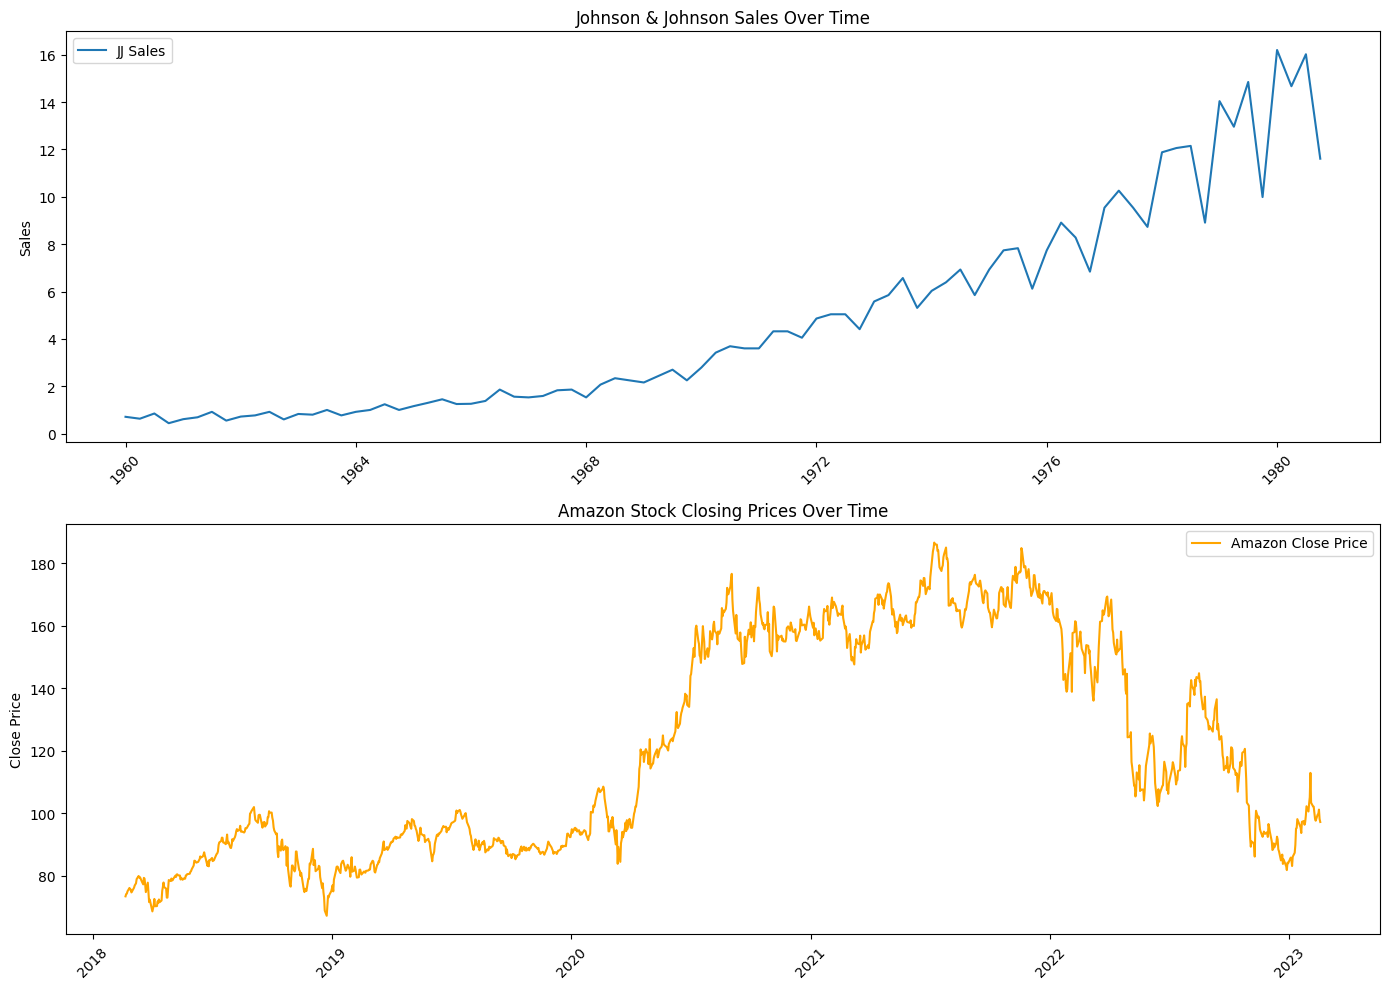

In [ ]:
# Convert 'date' and 'Date' columns to datetime
jj_data['date'] = pd.to_datetime(jj_data['date'])
amzn_data['Date'] = pd.to_datetime(amzn_data['Date'])

# Plot both JJ and Amazon
fig, axs = plt.subplots(2, 1, figsize=(14, 10))

# JJ Sales
axs[0].plot(jj_data['date'], jj_data['data'], label='JJ Sales')
axs[0].set_title('Johnson & Johnson Sales Over Time')
axs[0].set_ylabel('Sales')
axs[0].tick_params(axis='x', rotation=45)
axs[0].legend()

# Amazon Stock Price
axs[1].plot(amzn_data['Date'], amzn_data['Close'], label='Amazon Close Price', color='orange')
axs[1].set_title('Amazon Stock Closing Prices Over Time')
axs[1].set_ylabel('Close Price')
axs[1].tick_params(axis='x', rotation=45)
axs[1].legend()

plt.tight_layout()
plt.show()


### ADF Test, Log Transformation & Stationarity for JJ

In [ ]:
# ADF Test - Original JJ Sales
result = adfuller(jj_data['data'])
print("ADF Test Result for JJ Sales (Original)")
print('ADF Statistic:', result[0])
print('p-value:', result[1])
for key, val in result[4].items():
    print(f'Critical Value ({key}): {val}')

# Log Transform & First Differencing
jj_data['log_data'] = np.log(jj_data['data'])
jj_data['log_diff'] = jj_data['log_data'].diff()

# Drop NA values
jj_stationary = jj_data['log_diff'].dropna()

# ADF Test - After Differencing
result2 = adfuller(jj_stationary)
print("\nADF Test Result after Log Differencing")
print('ADF Statistic:', result2[0])
print('p-value:', result2[1])
for key, val in result2[4].items():
    print(f'Critical Value ({key}): {val}')


ADF Test Result for JJ Sales (Original)
ADF Statistic: 2.7420165734574744
p-value: 1.0
Critical Value (1%): -3.524624466842421
Critical Value (5%): -2.9026070739026064
Critical Value (10%): -2.5886785262345677

ADF Test Result after Log Differencing
ADF Statistic: -4.317043945811837
p-value: 0.00041497314044406584
Critical Value (1%): -3.518281134660583
Critical Value (5%): -2.899878185191432
Critical Value (10%): -2.5872229937594873


### ACF/PACF + ARIMA Fit + 24-Month Forecast (8 Quarters) for JJ

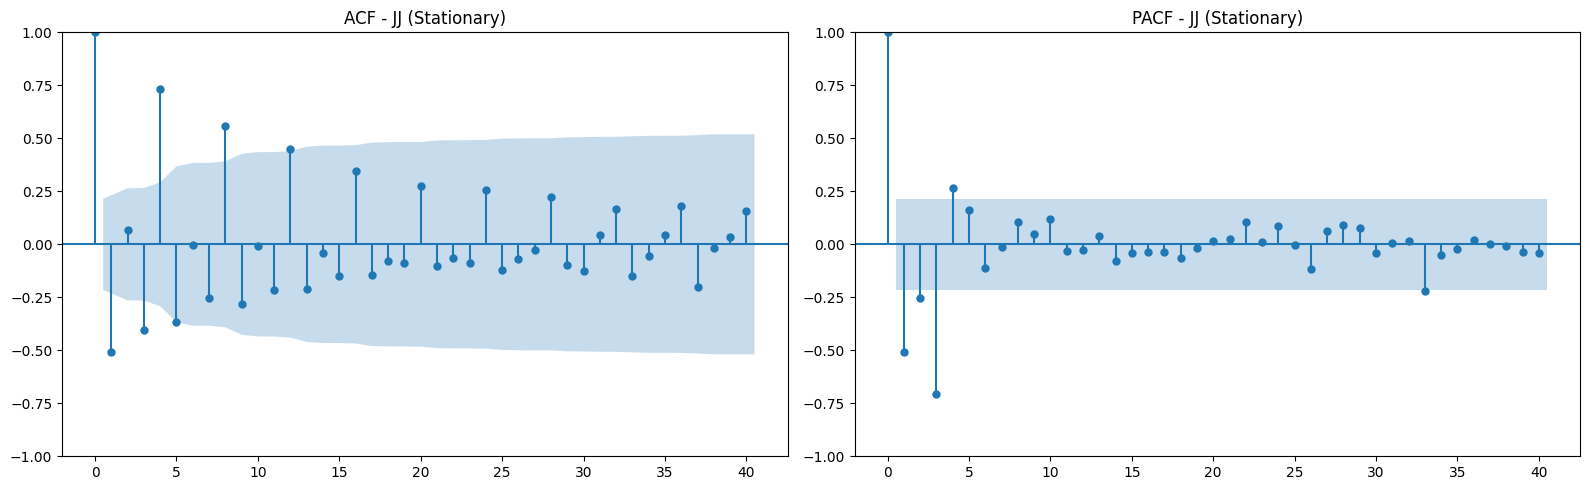


Best ARIMA order for JJ: (4, 1, 3)
Best AIC: -144.19887794840224
                               SARIMAX Results                                
Dep. Variable:               log_data   No. Observations:                   84
Model:                 ARIMA(4, 1, 3)   Log Likelihood                  80.099
Date:                Fri, 11 Apr 2025   AIC                           -144.199
Time:                        01:14:47   BIC                           -124.848
Sample:                             0   HQIC                          -136.425
                                 - 84                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0004      0.060     -0.007      0.994      -0.118       0.117
ar.L2          0.0141      0.049      0.286      0.775      -0.08

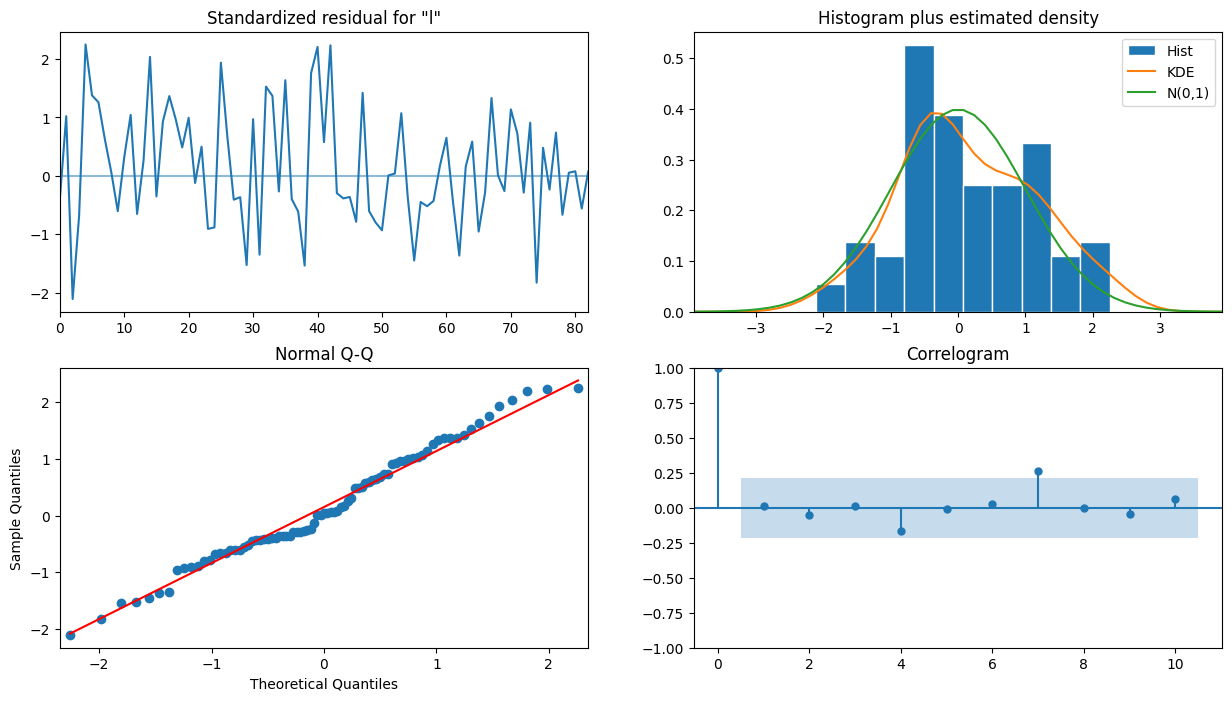

In [ ]:
# ACF and PACF for Stationary JJ Data
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(jj_stationary, lags=40, ax=axes[0])
axes[0].set_title('ACF - JJ (Stationary)')
plot_pacf(jj_stationary, lags=40, ax=axes[1])
axes[1].set_title('PACF - JJ (Stationary)')
plt.tight_layout()
plt.show()

# Grid Search for Best ARIMA(p,d,q)
p_values = range(0, 5)
d_values = [1]
q_values = range(0, 5)

best_aic = float("inf")
best_order = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(jj_data['log_data'].dropna(), order=(p, d, q))
                model_fit = model.fit()
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p, d, q)
            except:
                continue

print("\nBest ARIMA order for JJ:", best_order)
print("Best AIC:", best_aic)

# Final ARIMA Model for JJ
final_model_jj = ARIMA(jj_data['log_data'].dropna(), order=best_order)
final_model_jj_fit = final_model_jj.fit()
print(final_model_jj_fit.summary())

# Diagnostics
final_model_jj_fit.plot_diagnostics(figsize=(15, 8))
plt.show()


###  JJ Forecast – 8 Quarters (24 Months)

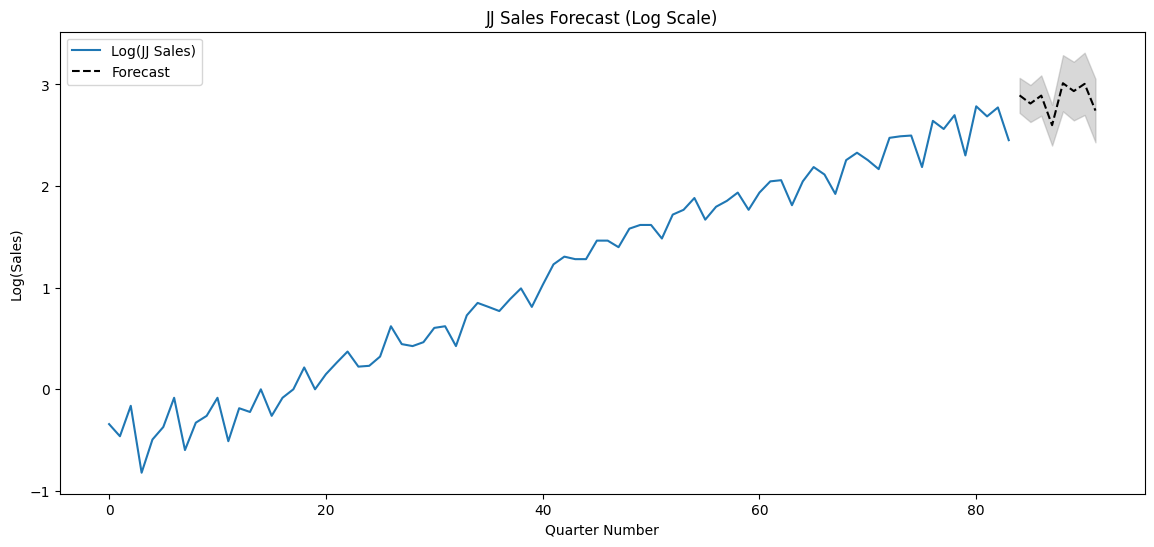

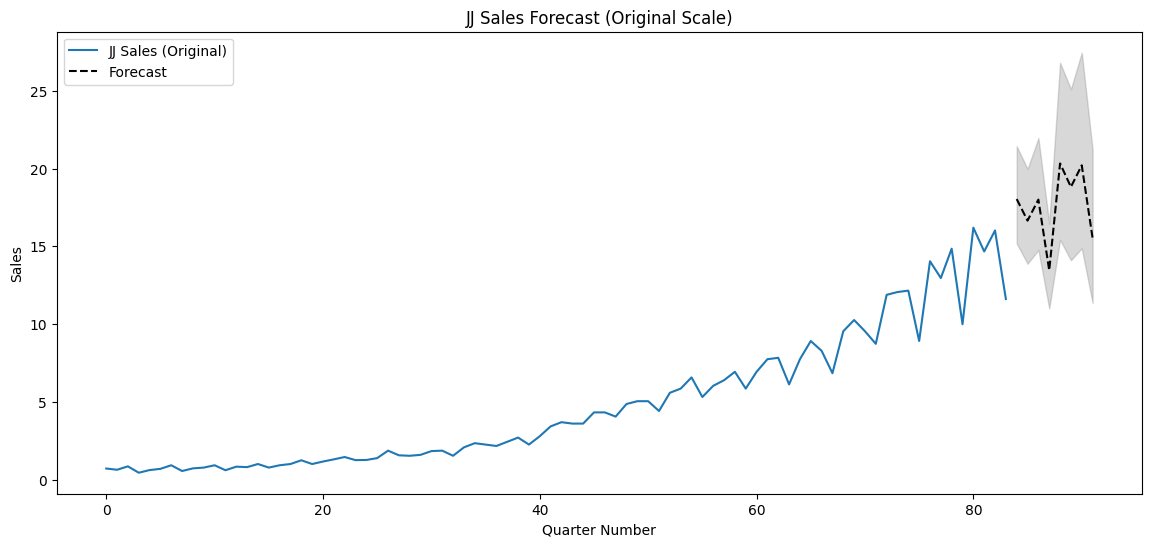

In [ ]:
# Forecasting 8 quarters ahead (24 months)
n_forecast = 8

forecast_result_jj = final_model_jj_fit.get_forecast(steps=n_forecast)
forecast_mean_jj = forecast_result_jj.predicted_mean
conf_int_jj = forecast_result_jj.conf_int()

# Forecast index (quarter numbers after end of training data)
forecast_index_jj = np.arange(len(jj_data['log_data'].dropna()),
                              len(jj_data['log_data'].dropna()) + n_forecast)

# Plot forecast in log scale
plt.figure(figsize=(14, 6))
plt.plot(np.log(jj_data['data']), label='Log(JJ Sales)')
plt.plot(forecast_index_jj, forecast_mean_jj, color='black', linestyle='--', label='Forecast')
plt.fill_between(forecast_index_jj, conf_int_jj.iloc[:, 0], conf_int_jj.iloc[:, 1], color='gray', alpha=0.3)
plt.title('JJ Sales Forecast (Log Scale)')
plt.xlabel('Quarter Number')
plt.ylabel('Log(Sales)')
plt.legend()
plt.show()

# Convert forecasted log values to original scale
forecast_sales_jj = np.exp(forecast_mean_jj)
conf_lower_jj = np.exp(conf_int_jj.iloc[:, 0])
conf_upper_jj = np.exp(conf_int_jj.iloc[:, 1])

# Plot forecast in original sales scale
plt.figure(figsize=(14, 6))
plt.plot(jj_data['data'], label='JJ Sales (Original)')
plt.plot(forecast_index_jj, forecast_sales_jj, color='black', linestyle='--', label='Forecast')
plt.fill_between(forecast_index_jj, conf_lower_jj, conf_upper_jj, color='gray', alpha=0.3)
plt.title('JJ Sales Forecast (Original Scale)')
plt.xlabel('Quarter Number')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [ ]:
# In-sample predictions (skip first value to match lengths after differencing)
in_sample_preds_jj = final_model_jj_fit.predict(start=1, end=len(jj_data['log_data'].dropna()) - 1, typ='levels')
true_values_jj = jj_data['log_data'].dropna().iloc[1:]

# RMSE and MAE in log scale
rmse_log_jj = np.sqrt(mean_squared_error(true_values_jj, in_sample_preds_jj))
mae_log_jj = mean_absolute_error(true_values_jj, in_sample_preds_jj)

# Convert to original scale
rmse_orig_jj = np.sqrt(mean_squared_error(np.exp(true_values_jj), np.exp(in_sample_preds_jj)))
mae_orig_jj = mean_absolute_error(np.exp(true_values_jj), np.exp(in_sample_preds_jj))

# Print metrics
print("JJ RMSE (log scale):", rmse_log_jj)
print("JJ MAE (log scale):", mae_log_jj)
print("JJ RMSE (original scale):", rmse_orig_jj)
print("JJ MAE (original scale):", mae_orig_jj)


JJ RMSE (log scale): 0.1034030261985274
JJ MAE (log scale): 0.07827848318155671
JJ RMSE (original scale): 0.40525883449000033
JJ MAE (original scale): 0.2796998931714936


## Amazon

### Amazon – Preprocessing, ADF Test, Log Transformation

In [ ]:
# ADF Test - Original Amazon Close Prices
adf_result_amzn = adfuller(amzn_data['Close'])
print("ADF Statistic (Amazon):", adf_result_amzn[0])
print("p-value:", adf_result_amzn[1])
for key, value in adf_result_amzn[4].items():
    print(f"Critical Value ({key}): {value}")

# Log transformation and differencing
amzn_data['log_close'] = np.log(amzn_data['Close'])
amzn_data['log_diff'] = amzn_data['log_close'].diff()
amzn_stationary = amzn_data['log_diff'].dropna()

# ADF Test - After Differencing
adf_result_amzn_diff = adfuller(amzn_stationary)
print("\nADF after differencing (Amazon)")
print("ADF Statistic:", adf_result_amzn_diff[0])
print("p-value:", adf_result_amzn_diff[1])
for key, value in adf_result_amzn_diff[4].items():
    print(f"Critical Value ({key}): {value}")


ADF Statistic (Amazon): -1.6578089913331728
p-value: 0.45297105465166737
Critical Value (1%): -3.4355588184378574
Critical Value (5%): -2.8638402312881497
Critical Value (10%): -2.5679946684494275

ADF after differencing (Amazon)
ADF Statistic: -36.639832812749425
p-value: 0.0
Critical Value (1%): -3.4355629707955395
Critical Value (5%): -2.863842063387667
Critical Value (10%): -2.567995644141416


###  Amazon ACF/PACF + ARIMA Fit

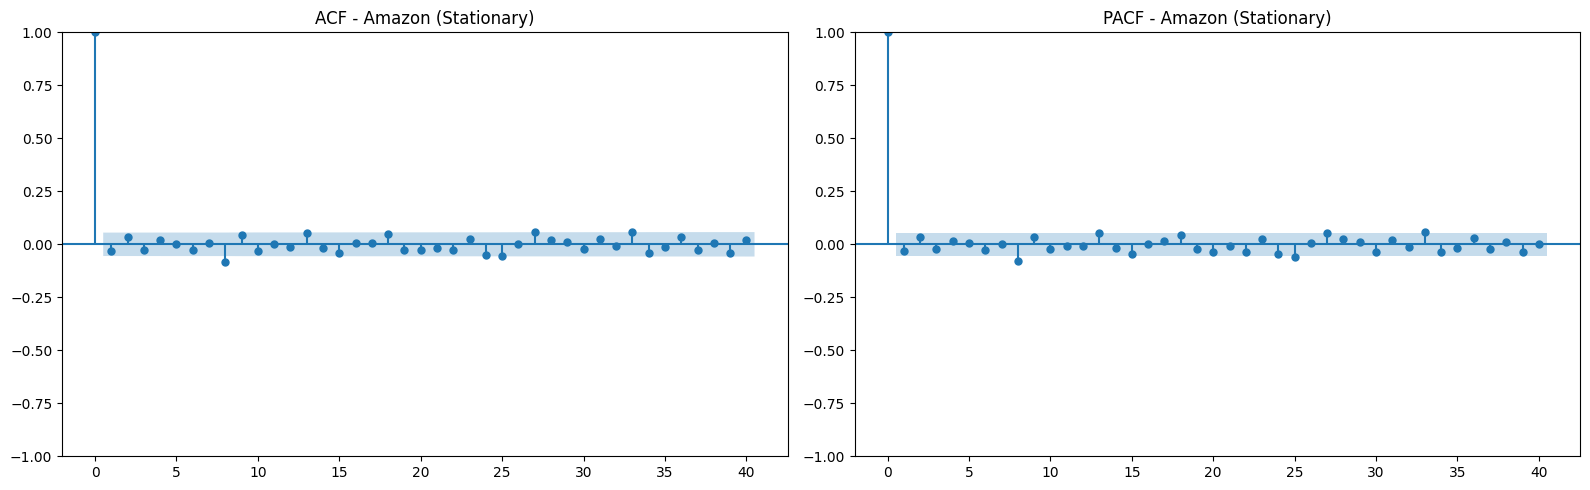


Best ARIMA order for Amazon: (0, 1, 0)
Best AIC: -5940.3401789290565
                               SARIMAX Results                                
Dep. Variable:              log_close   No. Observations:                 1259
Model:                 ARIMA(0, 1, 0)   Log Likelihood                2971.170
Date:                Fri, 11 Apr 2025   AIC                          -5940.340
Time:                        01:18:31   BIC                          -5935.203
Sample:                             0   HQIC                         -5938.410
                               - 1259                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0005   1.19e-05     43.798      0.000       0.000       0.001
Ljung-Box (L1) (Q):                   1.43   Jarque-Bera (JB)

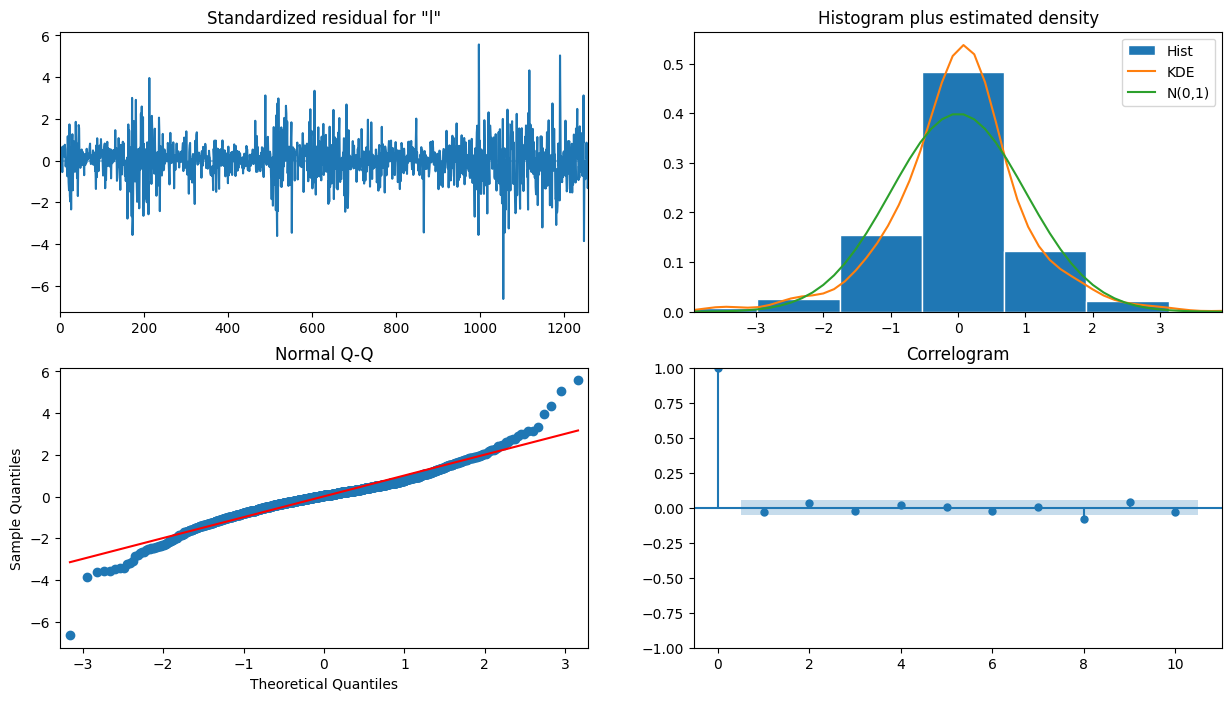

In [ ]:
# ACF and PACF for Stationary Amazon Series
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(amzn_stationary, lags=40, ax=axes[0])
axes[0].set_title('ACF - Amazon (Stationary)')
plot_pacf(amzn_stationary, lags=40, ax=axes[1])
axes[1].set_title('PACF - Amazon (Stationary)')
plt.tight_layout()
plt.show()

# Grid Search for Best ARIMA(p,d,q)
p_values = range(0, 5)
d_values = [1]
q_values = range(0, 5)

best_aic = float("inf")
best_order_amzn = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(amzn_data['log_close'].dropna(), order=(p, d, q))
                model_fit = model.fit()
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order_amzn = (p, d, q)
            except:
                continue

print("\nBest ARIMA order for Amazon:", best_order_amzn)
print("Best AIC:", best_aic)

# Fit Final Model for Amazon
final_model_amzn = ARIMA(amzn_data['log_close'].dropna(), order=best_order_amzn)
final_model_amzn_fit = final_model_amzn.fit()
print(final_model_amzn_fit.summary())

# Diagnostics
final_model_amzn_fit.plot_diagnostics(figsize=(15, 8))
plt.show()


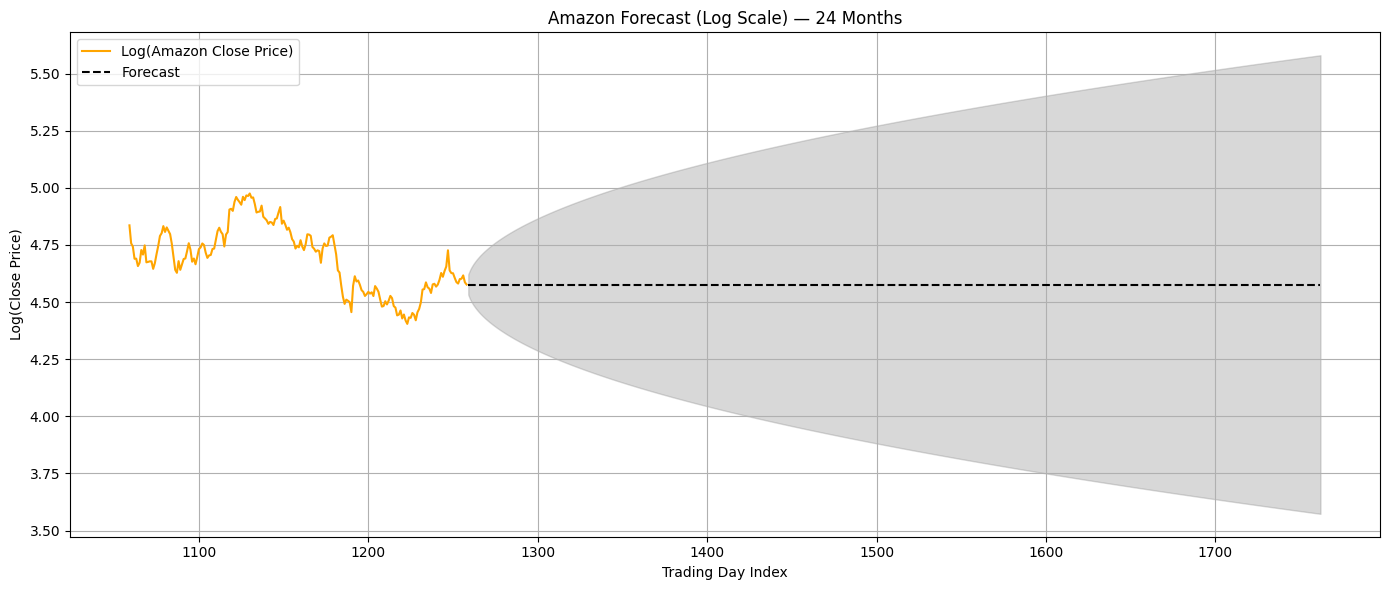

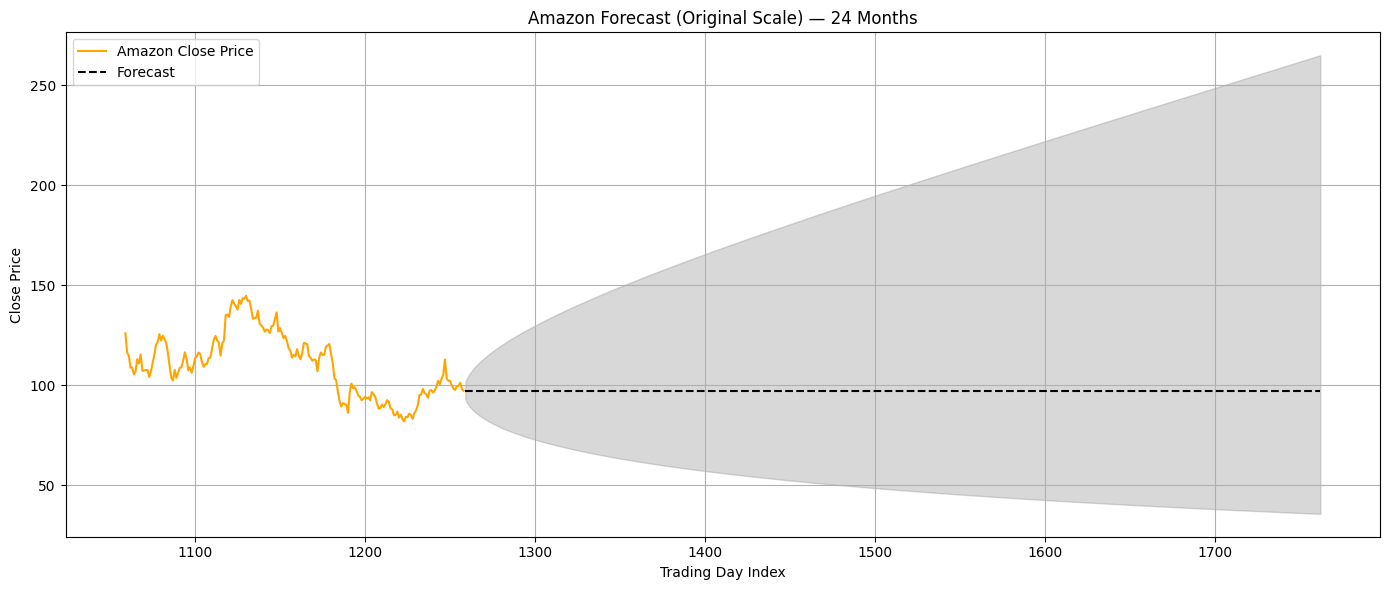

In [ ]:
# Forecasting 504 trading days (approx. 24 months)
n_forecast = 504

forecast_result_amzn = final_model_amzn_fit.get_forecast(steps=n_forecast)
forecast_mean_amzn = forecast_result_amzn.predicted_mean
conf_int_amzn = forecast_result_amzn.conf_int()

# Index for forecast plotting
forecast_index_amzn = np.arange(len(amzn_data['log_close'].dropna()),
                                 len(amzn_data['log_close'].dropna()) + n_forecast)

# Plot - Log Scale Forecast with last 200 actual values
lookback = 200
recent_actual = np.log(amzn_data['Close'].values[-lookback:])

plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(amzn_data['log_close']) - lookback, len(amzn_data['log_close'])),
         recent_actual, label='Log(Amazon Close Price)', color='orange')

plt.plot(forecast_index_amzn, forecast_mean_amzn, linestyle='--', color='black', label='Forecast')
plt.fill_between(forecast_index_amzn, conf_int_amzn.iloc[:, 0], conf_int_amzn.iloc[:, 1], alpha=0.3, color='gray')

plt.title('Amazon Forecast (Log Scale) — 24 Months')
plt.xlabel('Trading Day Index')
plt.ylabel('Log(Close Price)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Convert forecast back to original scale
forecast_sales_amzn = np.exp(forecast_mean_amzn)
conf_lower_amzn = np.exp(conf_int_amzn.iloc[:, 0])
conf_upper_amzn = np.exp(conf_int_amzn.iloc[:, 1])

# Plot - Original Scale Forecast with last 200 actual values
recent_actual_orig = amzn_data['Close'].values[-lookback:]

plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(amzn_data['Close']) - lookback, len(amzn_data['Close'])),
         recent_actual_orig, label='Amazon Close Price', color='orange')

plt.plot(forecast_index_amzn, forecast_sales_amzn, color='black', linestyle='--', label='Forecast')
plt.fill_between(forecast_index_amzn, conf_lower_amzn, conf_upper_amzn, color='gray', alpha=0.3)

plt.title('Amazon Forecast (Original Scale) — 24 Months')
plt.xlabel('Trading Day Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# In-sample prediction (skip first value to match lengths)
in_sample_preds_amzn = final_model_amzn_fit.predict(
    start=1, end=len(amzn_data['log_close'].dropna()) - 1, typ='levels'
)
true_values_amzn = amzn_data['log_close'].dropna().iloc[1:]

# RMSE and MAE in log scale
rmse_log_amzn = np.sqrt(mean_squared_error(true_values_amzn, in_sample_preds_amzn))
mae_log_amzn = mean_absolute_error(true_values_amzn, in_sample_preds_amzn)

# Convert to original scale
rmse_orig_amzn = np.sqrt(mean_squared_error(np.exp(true_values_amzn), np.exp(in_sample_preds_amzn)))
mae_orig_amzn = mean_absolute_error(np.exp(true_values_amzn), np.exp(in_sample_preds_amzn))

# Print metrics
print("Amazon RMSE (log scale):", rmse_log_amzn)
print("Amazon MAE (log scale):", mae_log_amzn)
print("Amazon RMSE (original scale):", rmse_orig_amzn)
print("Amazon MAE (original scale):", mae_orig_amzn)


Amazon RMSE (log scale): 0.022805375588248987
Amazon MAE (log scale): 0.016084048183029578
Amazon RMSE (original scale): 2.764686871390017
Amazon MAE (original scale): 1.916432104941939


# LSTM

In [ ]:
# LSTM and Deep Learning Imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.18.0


## jj

###  JJ – Scaling + Sequence Creation for LSTM

In [ ]:
# Use only the sales data for JJ
jj_values = jj_data['data'].values.reshape(-1, 1)

# Scale the data between 0 and 1
scaler_jj = MinMaxScaler(feature_range=(0, 1))
jj_scaled = scaler_jj.fit_transform(jj_values)

# Define sequence window size
sequence_length = 5  # You can tune this (e.g., 5 means using 5 past quarters to predict next)

# Create sequences
X_jj, y_jj = [], []
for i in range(sequence_length, len(jj_scaled)):
    X_jj.append(jj_scaled[i - sequence_length:i])
    y_jj.append(jj_scaled[i])

X_jj = np.array(X_jj)
y_jj = np.array(y_jj)

# Reshape input to [samples, time steps, features] for LSTM
print("X shape:", X_jj.shape)
print("y shape:", y_jj.shape)


X shape: (79, 5, 1)
y shape: (79, 1)


### Build & Train the LSTM Model for JJ

In [ ]:
# Define the LSTM model
model_jj = Sequential()
model_jj.add(LSTM(50, activation='relu', input_shape=(X_jj.shape[1], 1)))
model_jj.add(Dense(1))

# Compile
model_jj.compile(optimizer='adam', loss='mean_squared_error')

# Train
history = model_jj.fit(X_jj, y_jj, epochs=100, batch_size=8, verbose=1)


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1375
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1193  
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0921 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0731 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0442 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0263 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0181 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0105 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0059 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0050 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047 
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 
Epoch 15/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - los

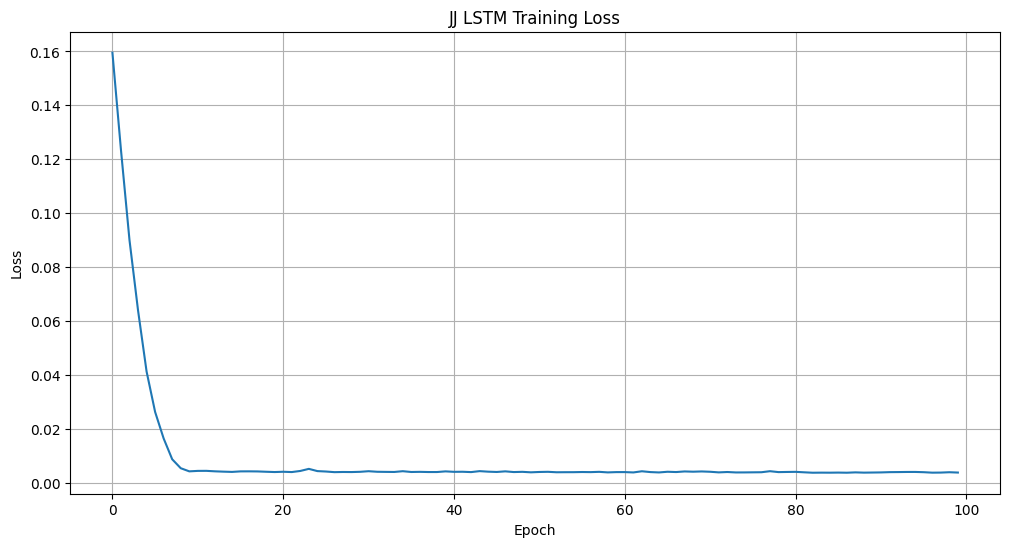

In [ ]:
# Plot training loss
plt.plot(history.history['loss'])
plt.title('JJ LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### Forecast Next 8 Quarters with LSTM

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


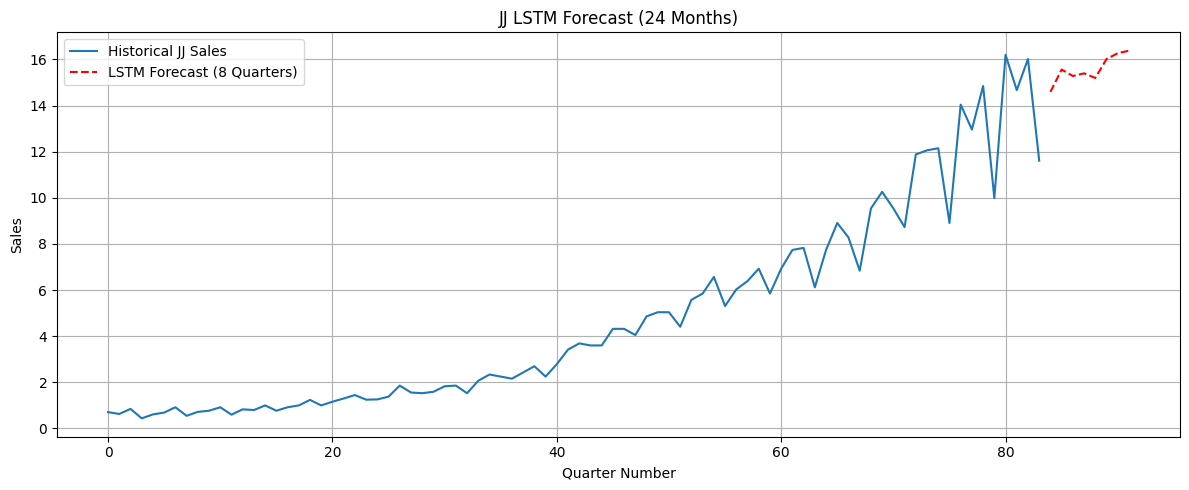

In [ ]:
# Start with last 5 known values
last_input = jj_scaled[-sequence_length:].reshape(1, sequence_length, 1)

future_preds_jj_scaled = []

# Predict 8 quarters into the future (recursive)
for _ in range(8):
    next_pred = model_jj.predict(last_input)[0]
    future_preds_jj_scaled.append(next_pred)

    # Update input window
    last_input = np.append(last_input[:, 1:, :], [[next_pred]], axis=1)

# Inverse scale the predictions to original values
future_preds_jj = scaler_jj.inverse_transform(np.array(future_preds_jj_scaled))

# Plot forecast
future_quarters = np.arange(len(jj_data), len(jj_data) + 8)

plt.figure(figsize=(12, 5))
plt.plot(jj_data['data'], label='Historical JJ Sales')
plt.plot(future_quarters, future_preds_jj, 'r--', label='LSTM Forecast (8 Quarters)')
plt.title('JJ LSTM Forecast (24 Months)')
plt.xlabel('Quarter Number')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Amazon

### Amazon – Scaling & Sequence Creation for LSTM

In [ ]:
# Use only the 'Close' prices
amzn_values = amzn_data['Close'].values.reshape(-1, 1)

# Scale between 0 and 1
scaler_amzn = MinMaxScaler(feature_range=(0, 1))
amzn_scaled = scaler_amzn.fit_transform(amzn_values)

# Define sequence length (e.g., 60 days)
sequence_length = 60

# Create LSTM sequences
X_amzn, y_amzn = [], []
for i in range(sequence_length, len(amzn_scaled)):
    X_amzn.append(amzn_scaled[i-sequence_length:i])
    y_amzn.append(amzn_scaled[i])

X_amzn = np.array(X_amzn)
y_amzn = np.array(y_amzn)

print("X_amzn shape:", X_amzn.shape)
print("y_amzn shape:", y_amzn.shape)


X_amzn shape: (1199, 60, 1)
y_amzn shape: (1199, 1)


### Build & Train the LSTM Model for Amazon

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.2010
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0062
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0031
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0031
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0027
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0027
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0023
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0021
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0021
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0021
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0019
Epoch 12/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0020
Epoch 13/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0019
Epoch 14/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0018
Epoch 15/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0016
Epoc

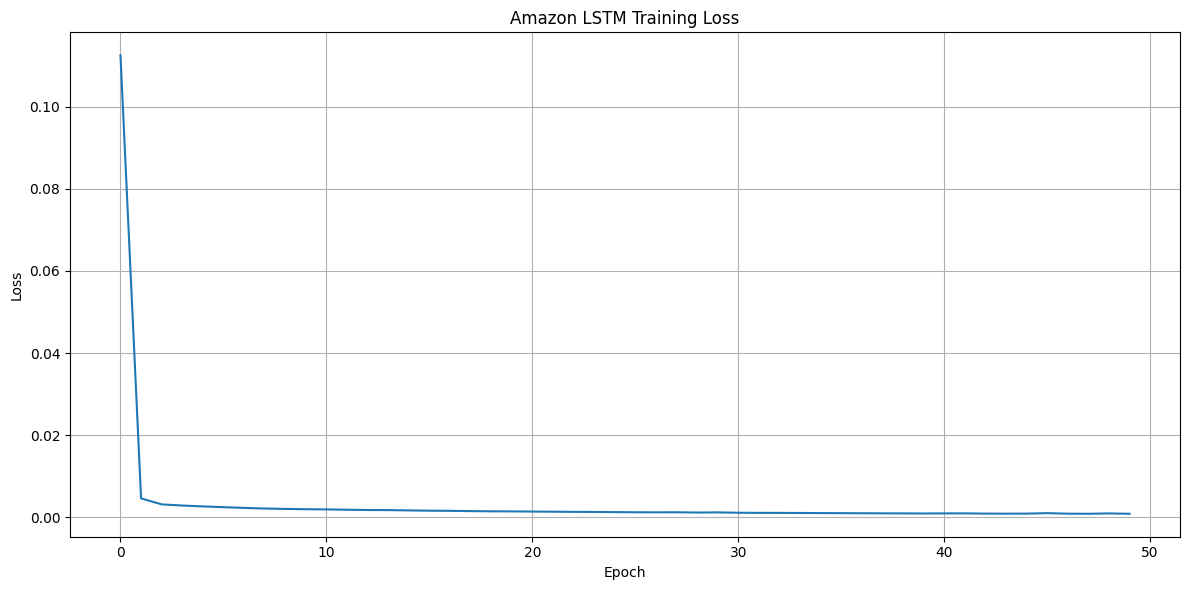

In [ ]:
# Define the model
model_amzn = Sequential()
model_amzn.add(LSTM(50, activation='relu', input_shape=(X_amzn.shape[1], 1)))
model_amzn.add(Dense(1))

# Compile the model
model_amzn.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history_amzn = model_amzn.fit(X_amzn, y_amzn, epochs=50, batch_size=32, verbose=1)

# Plot training loss
plt.plot(history_amzn.history['loss'])
plt.title('Amazon LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()


### Forecast Next 24 months with LSTM (Amazon)

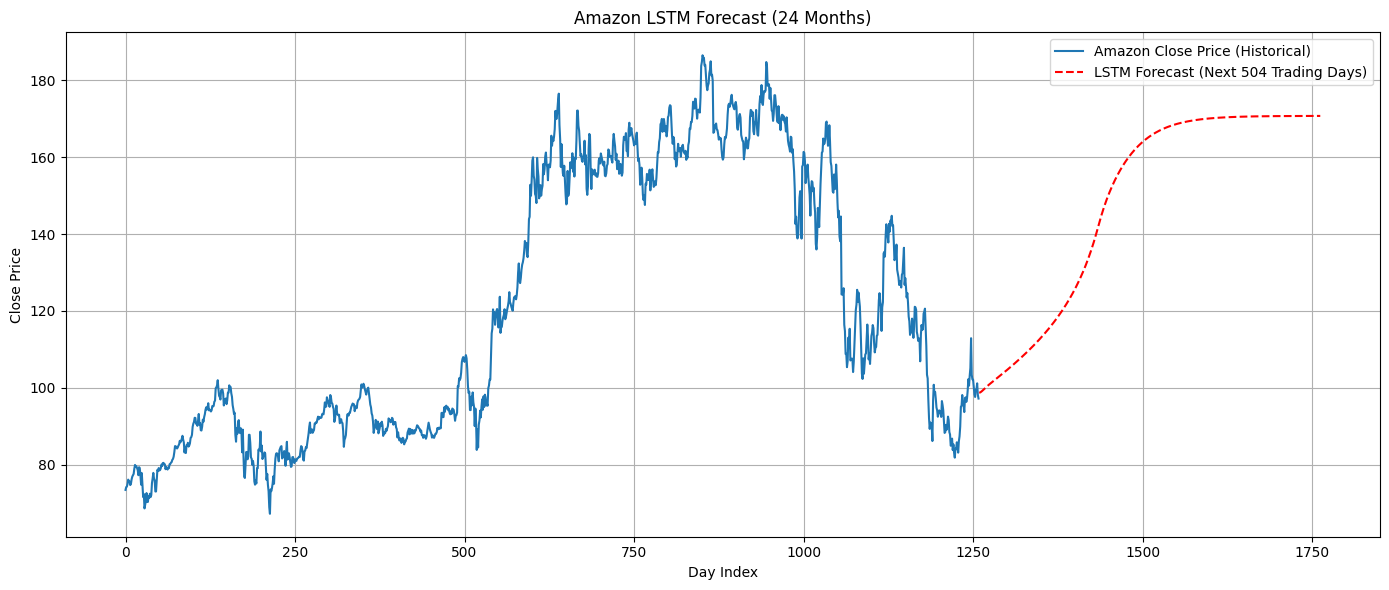

In [ ]:
# Start with last 60 known values
last_input_amzn = amzn_scaled[-sequence_length:].reshape(1, sequence_length, 1)

future_preds_amzn_scaled = []

# Forecast 504 trading days ahead
for _ in range(504):
    next_pred = model_amzn.predict(last_input_amzn, verbose=0)[0]
    future_preds_amzn_scaled.append(next_pred)

    # Shift window and append new prediction
    last_input_amzn = np.append(last_input_amzn[:, 1:, :], [[next_pred]], axis=1)

# Inverse transform the scaled predictions to original price
future_preds_amzn = scaler_amzn.inverse_transform(np.array(future_preds_amzn_scaled))

# Build the time index for forecast
future_days = np.arange(len(amzn_data), len(amzn_data) + 504)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(amzn_data['Close'], label='Amazon Close Price (Historical)')
plt.plot(future_days, future_preds_amzn, 'r--', label='LSTM Forecast (Next 504 Trading Days)')
plt.title('Amazon LSTM Forecast (24 Months)')
plt.xlabel('Day Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### JJ RMSE & MAE for LSTM

In [ ]:
# Predict on training set
train_preds_jj_scaled = model_jj.predict(X_jj)

# Inverse transform
train_preds_jj = scaler_jj.inverse_transform(train_preds_jj_scaled)
y_jj_orig = scaler_jj.inverse_transform(y_jj)

# Calculate metrics
rmse_jj_lstm = np.sqrt(mean_squared_error(y_jj_orig, train_preds_jj))
mae_jj_lstm = mean_absolute_error(y_jj_orig, train_preds_jj)

print("JJ LSTM RMSE:", rmse_jj_lstm)
print("JJ LSTM MAE:", mae_jj_lstm)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 
JJ LSTM RMSE: 0.9373869233049265
JJ LSTM MAE: 0.5338588449451108


###  Amazon – RMSE & MAE for LSTM

In [ ]:
# Predict on training set
train_preds_amzn_scaled = model_amzn.predict(X_amzn)

# Inverse transform
train_preds_amzn = scaler_amzn.inverse_transform(train_preds_amzn_scaled)
y_amzn_orig = scaler_amzn.inverse_transform(y_amzn)

# Calculate metrics
rmse_amzn_lstm = np.sqrt(mean_squared_error(y_amzn_orig, train_preds_amzn))
mae_amzn_lstm = mean_absolute_error(y_amzn_orig, train_preds_amzn)

print("Amazon LSTM RMSE:", rmse_amzn_lstm)
print("Amazon LSTM MAE:", mae_amzn_lstm)


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Amazon LSTM RMSE: 3.42283793119804
Amazon LSTM MAE: 2.48249285912251
